# 03 — Ablation Exp 1–6 (proposal 3.3.3) → RQ1

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))  # so `import src...` works from notebooks/

import numpy as np
import pandas as pd

from src import config
from src.utils import set_seed, save_fig
set_seed()  # fix all RNGs -- reproducibility

Six conditions, identical classifier + protocol. TF-IDF sparse + dense → `sparse.hstack` in `features.assemble`. Add LinearSVM (all), MultinomialNB (TF-IDF conditions only — non-negative).

In [2]:
from src import data, features, modeling
clean = data.load_or_build_clean(); splits = data.load_or_build_splits(clean)
y = clean[config.LABEL_COL].values

In [3]:
# Build every block ONCE, then assemble per experiment.
texts = clean['text']
X_tfidf, _ = features.build_tfidf(texts.iloc[splits['train']], texts)
sty = features.build_stylometric(texts)
sty_scaled, _ = features.scale_dense(sty.values, splits['train'])
bib = features.build_biber(texts)
bib_scaled, _ = features.scale_dense(bib.values, splits['train'])
emb = features.build_sbert(texts)   # cached

blocks = {
    'tfidf':       X_tfidf,
    'stylometric': sty_scaled,
    'biber':       bib_scaled,
    'sbert':       emb,
    'length':      clean[['log_token_count']].values,
}

In [4]:
# NB needs non-negative input everywhere -- only exp1 (pure TF-IDF + length,
# both non-negative) qualifies. Scaled dense blocks are mean-centered, so any
# experiment mixing them in would violate MultinomialNB's assumption even if
# it also contains tfidf (proposal 3.2: "TF-IDF-based conditions ... non-negative").
import time

CLASSIFIERS_BY_EXP = {'exp1_tfidf': ['logreg', 'svm', 'nb']}
DEFAULT_CLASSIFIERS = ['logreg', 'svm']

ytr, yval = y[splits['train']], y[splits['val']]
results = {}
t_start = time.time()
for exp_name, which in features.EXPERIMENTS.items():
    X = features.assemble(blocks, which, splits['train'])
    Xtr, Xval = X[splits['train']], X[splits['val']]

    for clf_name in CLASSIFIERS_BY_EXP.get(exp_name, DEFAULT_CLASSIFIERS):
        t0 = time.time()
        results[(exp_name, clf_name)] = modeling.train_and_evaluate(clf_name, Xtr, ytr, Xval, yval)
        elapsed, total = time.time() - t0, time.time() - t_start
        print(f'[{total/60:6.1f} min total] {exp_name:18s} {clf_name:6s} done in {elapsed:6.1f}s '
              f'(macro_f1={results[(exp_name, clf_name)].macro_f1:.3f})')

results_df = pd.DataFrame({
    (exp, clf): {'macro_f1': r.macro_f1, 'weighted_f1': r.weighted_f1, 'accuracy': r.accuracy}
    for (exp, clf), r in results.items()
}).T
results_df.index.names = ['experiment', 'classifier']
results_df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[  10.9 min total] exp1_tfidf         logreg done in  653.8s (macro_f1=0.710)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[  26.6 min total] exp1_tfidf         svm    done in  941.7s (macro_f1=0.667)
[  26.6 min total] exp1_tfidf         nb     done in    0.5s (macro_f1=0.572)
[  27.1 min total] exp2_style         logreg done in   28.7s (macro_f1=0.394)
[  27.1 min total] exp2_style         svm    done in    2.8s (macro_f1=0.356)
[  29.9 min total] exp3_sbert         logreg done in  166.8s (macro_f1=0.417)
[  31.9 min total] exp3_sbert         svm    done in  119.9s (macro_f1=0.378)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[ 114.7 min total] exp6_all           logreg done in 2463.1s (macro_f1=0.720)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[ 159.6 min total] exp6_all           svm    done in 2690.0s (macro_f1=0.683)


macro_f1  weighted_f1  accuracy
experiment       classifier                                 
exp1_tfidf       logreg      0.710281     0.710439  0.709866
                 svm         0.666572     0.666744  0.667194
                 nb          0.571662     0.571746  0.573412
exp2_style       logreg      0.394232     0.394008  0.411250
                 svm         0.355764     0.355570  0.399824
exp3_sbert       logreg      0.417066     0.416863  0.425357
                 svm         0.378399     0.378212  0.409185
exp4_tfidf_style logreg      0.715150     0.715303  0.714832
                 svm         0.675079     0.675224  0.676071
exp5_style_sbert logreg      0.494612     0.494499  0.503670
                 svm         0.466703     0.466580  0.492815
exp6_all         logreg      0.720066     0.720218  0.719710
                 svm         0.683315     0.683480  0.684465

Save the results table for the report.

In [5]:
results_df.to_csv(config.ARTIFACTS / 'ablation_results.csv')

PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/ablation_macro_f1.png')

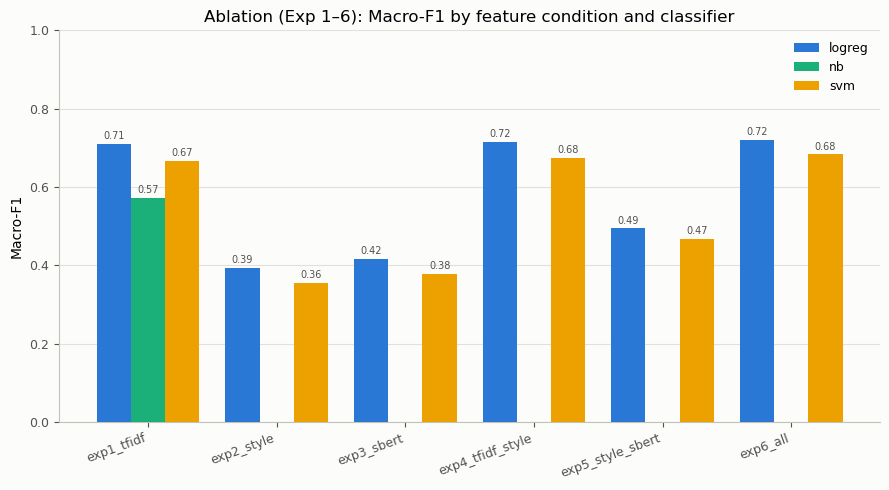

In [6]:
from src import viz

pivot = results_df['macro_f1'].unstack('classifier').reindex(features.EXPERIMENTS.keys())

fig, ax = viz.new_fig(figsize=(9, 5))
n_clf = len(pivot.columns)
width = 0.8 / n_clf
x = np.arange(len(pivot))
for i, clf in enumerate(pivot.columns):
    vals = pivot[clf].values
    valid = ~np.isnan(vals)
    offset = (i - (n_clf - 1) / 2) * width
    bars = ax.bar(x[valid] + offset, vals[valid], width, label=clf,
                   color=viz.CATEGORICAL[i], zorder=3)
    ax.bar_label(bars, fmt='%.2f', fontsize=7, color=viz.INK_SECONDARY, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=20, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1)
ax.set_title('Ablation (Exp 1–6): Macro-F1 by feature condition and classifier')
ax.legend(frameon=False, fontsize=9, title=None)
fig.tight_layout()
save_fig(fig, 'ablation_macro_f1')